In [2]:
%pip install -r requirements.txt

  Using cached pandas-3.0.1-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached pandas-3.0.1-cp311-cp311-win_amd64.whl (9.9 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
    --------------------------------------- 0.0/1.5 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.5 MB 487.6 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.5 MB 655.4 kB/s eta 0:00:03
   ---- --------------------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importing Libraries :

In [3]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score

# Models
import lightgbm as lgb
import xgboost as xgb

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Load Data

In [4]:
train = pd.read_csv('Data/train_data.csv')
test = pd.read_csv('Data/test_data.csv')

print(train.shape, test.shape)
train.head()

(89392, 12) (59595, 11)


,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
0,1,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum,64308
1,2,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum,515400
2,3,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum,64212
3,4,Female,Rural,High School,5L-10L,0,7,0,More than 1,A,Platinum,97920
4,5,Male,Urban,High School,More than 10L,1,6,3508,More than 1,A,Gold,59736


# Basic EDA

In [5]:
train.info()
train.describe()

# Missing values
train.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 89392 entries, 0 to 89391
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              89392 non-null  int64
 1   gender          89392 non-null  str  
 2   area            89392 non-null  str  
 3   qualification   89392 non-null  str  
 4   income          89392 non-null  str  
 5   marital_status  89392 non-null  int64
 6   vintage         89392 non-null  int64
 7   claim_amount    89392 non-null  int64
 8   num_policies    89392 non-null  str  
 9   policy          89392 non-null  str  
 10  type_of_policy  89392 non-null  str  
 11  cltv            89392 non-null  int64
dtypes: int64(5), str(7)
memory usage: 8.2 MB


id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
cltv              0
dtype: int64

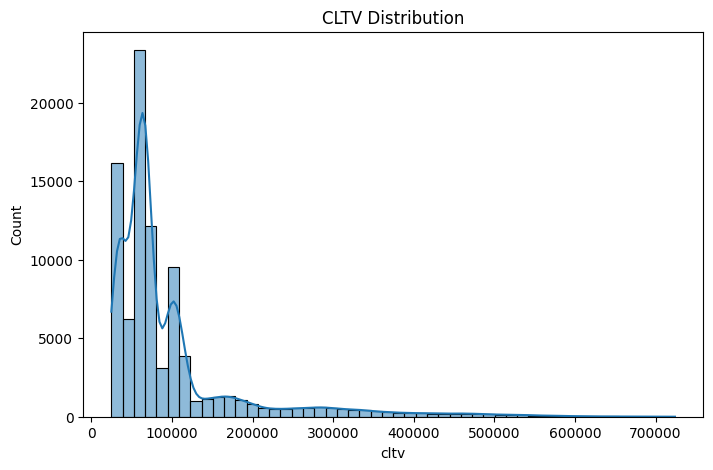

In [6]:
# Target distribution
plt.figure(figsize=(8,5))
sns.histplot(train['cltv'], bins=50, kde=True)
plt.title("CLTV Distribution")
plt.show()

Model Focuses on high-frequency low values , Performs poorly on high CLTV customers .  
Hence , I must transform the target :  
- Why log transform works :  
  - Compresses large values  
  - Reduces skewness  
  - Makes distribution more Gaussian-like  
  - Improves model learning  

In [ ]:
train['cltv_log'] = np.log1p(train['cltv'])